<a href="https://colab.research.google.com/github/cdhernandez5/ProfitMap--Javeriana/blob/main/src/4_Modelamiento%20Score%20Riesgo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 CRISP-DM — Fase de Modelamiento y Evaluación
## Predicción de Score de Riesgo Trimestral_-_



### Variables objetivo:
| Variable | Tipo | Tarea |
|---|---|---|
| `risk_score_next` | Continua [0,1] | **Regresión** |
| `target_distress_next` | Binaria {0,1} | **Clasificación binaria** |
| `target_class_next` | Multiclase {0,1,2} | **Clasificación multiclase** |

---

## 0. Importaciones y Configuración Global

In [ ]:
# ── Librerías base ──────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Preprocesamiento ────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ── Modelos de Regresión ────────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

# ── Modelos de Clasificación ────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# ── Métricas de Regresión ───────────────────────────────────────────────────
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

# ── Métricas de Clasificación ───────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

# ── Configuración visual ────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
RANDOM_STATE = 42

print('✅ Librerías importadas correctamente.')

✅ Librerías importadas correctamente.


## 1. Carga del Dataset

In [ ]:
# ── Ruta del dataset ────────────────────────────────────────────────────────
DATA_PATH = 'training_dataset_riesgo_trimestral_v1.csv'

df = pd.read_csv(DATA_PATH)

print(f'📂 Dataset cargado: {df.shape[0]:,} registros × {df.shape[1]} columnas')
print()
df.head(3)

📂 Dataset cargado: 85,924 registros × 31 columnas



,adsh,cik,name,sic,form,period,filed,fy,fp,periodo,...,flag_liquidez_critica,flag_fco_negativo,n_alertas,flag_deterioro,fp_orden.1,risk_score_0_1.1,altman_zscore,target_distress_next,target_class_next,risk_score_next
0,0001144204-18-053676,2034,ACETO CORP,5122.0,10-Q/A,20180331.0,1970-01-01 00:00:00.020181012,2018,Q3,2018-Q3,...,0,0,2,NaN,3,NaN,NaN,1,2,0.787804
1,0001144204-18-051414,2034,ACETO CORP,5122.0,10-K,20180630.0,1970-01-01 00:00:00.020180928,2018,FY,2018-FY,...,0,0,2,NaN,4,0.787804,-0.081741,1,1,0.632928
2,0001144204-18-058572,2034,ACETO CORP,5122.0,10-Q,20180930.0,1970-01-01 00:00:00.020181109,2019,Q1,2019-Q1,...,0,1,3,0.0,1,0.632928,0.685202,1,2,0.680331


## 2. Definición de Features y Variables Objetivo

In [ ]:
# ── Columnas de identificación (excluidas del modelo) ───────────────────────
ID_COLS = [
    'adsh', 'cik', 'name', 'sic', 'form', 'period',
    'filed', 'fy', 'fp', 'periodo', 'fp_orden', 'fp_orden.1',
    'countryba', 'stprba'
]

# ── Variables objetivo ──────────────────────────────────────────────────────
TARGET_REG    = 'risk_score_next'        # Regresión
TARGET_BIN    = 'target_distress_next'   # Clasificación binaria
TARGET_MULTI  = 'target_class_next'      # Clasificación multiclase

TARGET_COLS = [TARGET_REG, TARGET_BIN, TARGET_MULTI]

# ── Features ────────────────────────────────────────────────────────────────
FEATURE_COLS = [c for c in df.columns if c not in ID_COLS + TARGET_COLS]

print('🔧 Features utilizados:')
for f in FEATURE_COLS:
    nulls = df[f].isnull().sum()
    print(f'   • {f:<35} dtype={str(df[f].dtype):<10} nulls={nulls:,}')

print(f'\n🎯 Targets: {TARGET_COLS}')

🔧 Features utilizados:
   • risk_score_0_1                      dtype=float64    nulls=5,021
   • risk_score_prev                     dtype=float64    nulls=10,238
   • delta_risk_score                    dtype=float64    nulls=11,107
   • delta_risk_score_prev               dtype=float64    nulls=15,937
   • aceleracion_riesgo                  dtype=float64    nulls=16,616
   • flag_patrimonio_negativo            dtype=int64      nulls=0
   • flag_perdida_neta                   dtype=int64      nulls=0
   • flag_deficit_acumulado              dtype=int64      nulls=0
   • flag_liquidez_critica               dtype=int64      nulls=0
   • flag_fco_negativo                   dtype=int64      nulls=0
   • n_alertas                           dtype=int64      nulls=0
   • flag_deterioro                      dtype=float64    nulls=11,107
   • risk_score_0_1.1                    dtype=float64    nulls=5,021
   • altman_zscore                       dtype=float64    nulls=5,021

🎯 Targets: ['ri

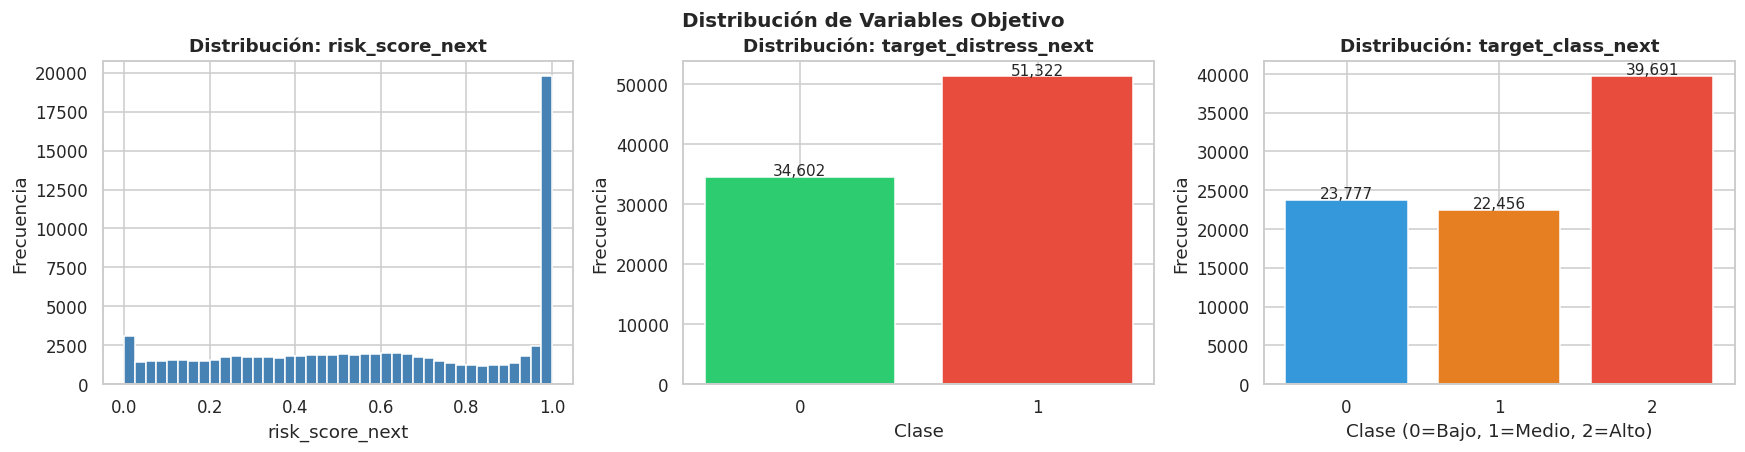

In [ ]:
# ── Resumen de distribución de targets ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Regresión
axes[0].hist(df[TARGET_REG].dropna(), bins=40, color='steelblue', edgecolor='white')
axes[0].set_title(f'Distribución: {TARGET_REG}', fontweight='bold')
axes[0].set_xlabel('risk_score_next')
axes[0].set_ylabel('Frecuencia')

# Binaria
vc_bin = df[TARGET_BIN].value_counts().sort_index()
axes[1].bar(vc_bin.index.astype(str), vc_bin.values, color=['#2ecc71','#e74c3c'])
axes[1].set_title(f'Distribución: {TARGET_BIN}', fontweight='bold')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Frecuencia')
for i, v in enumerate(vc_bin.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

# Multiclase
vc_mc = df[TARGET_MULTI].value_counts().sort_index()
colors_mc = ['#3498db','#e67e22','#e74c3c']
axes[2].bar(vc_mc.index.astype(str), vc_mc.values, color=colors_mc)
axes[2].set_title(f'Distribución: {TARGET_MULTI}', fontweight='bold')
axes[2].set_xlabel('Clase (0=Bajo, 1=Medio, 2=Alto)')
axes[2].set_ylabel('Frecuencia')
for i, v in enumerate(vc_mc.values):
    axes[2].text(i, v + 200, f'{v:,}', ha='center', fontsize=10)

plt.tight_layout()
plt.suptitle('Distribución de Variables Objetivo', fontsize=13, fontweight='bold', y=1.02)
plt.show()

## 3. Preparación de Datos para Modelamiento

In [ ]:
X = df[FEATURE_COLS].copy()

# ── Pipeline de preprocesamiento (imputación + escalado) ────────────────────
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

X_processed = preprocessor.fit_transform(X)
X_processed = pd.DataFrame(X_processed, columns=FEATURE_COLS)

print(f'✅ Features procesados: {X_processed.shape}')
print(f'   Valores nulos tras imputación: {X_processed.isnull().sum().sum()}')

✅ Features procesados: (85924, 14)
   Valores nulos tras imputación: 0


In [ ]:
# ── Splits por variable objetivo ────────────────────────────────────────────
TEST_SIZE = 0.20

# Regresión
y_reg = df[TARGET_REG]
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_processed, y_reg, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

# Binaria
y_bin = df[TARGET_BIN]
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_processed, y_bin, test_size=TEST_SIZE,
    stratify=y_bin, random_state=RANDOM_STATE
)

# Multiclase
y_mc = df[TARGET_MULTI]
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_processed, y_mc, test_size=TEST_SIZE,
    stratify=y_mc, random_state=RANDOM_STATE
)

print('📦 Tamaños de conjuntos:')
print(f'   Regresión   → Train: {X_train_r.shape[0]:,} | Test: {X_test_r.shape[0]:,}')
print(f'   Binaria     → Train: {X_train_b.shape[0]:,} | Test: {X_test_b.shape[0]:,}')
print(f'   Multiclase  → Train: {X_train_m.shape[0]:,} | Test: {X_test_m.shape[0]:,}')

📦 Tamaños de conjuntos:
   Regresión   → Train: 68,739 | Test: 17,185
   Binaria     → Train: 68,739 | Test: 17,185
   Multiclase  → Train: 68,739 | Test: 17,185


---
## 4. Modelamiento — Tarea 1: Regresión (`risk_score_next`)

Modelos a evaluar: **Linear Regression, Ridge, Lasso, ElasticNet, KNN, SVR, Random Forest, Gradient Boosting, Extra Trees**

In [ ]:
# ── Definición de modelos de regresión ─────────────────────────────────────
regression_models = {
    'Linear Regression' : LinearRegression(),
    'Ridge'             : Ridge(alpha=1.0, random_state=RANDOM_STATE),
    'Lasso'             : Lasso(alpha=0.001, random_state=RANDOM_STATE, max_iter=5000),
    'ElasticNet'        : ElasticNet(alpha=0.001, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000),
    'KNN Regressor'     : KNeighborsRegressor(n_neighbors=10),
    'SVR (RBF)'         : SVR(kernel='rbf', C=1.0),
    'Random Forest'     : RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting' : GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=RANDOM_STATE),
    'Extra Trees'       : ExtraTreesRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
}

print(f'🔢 Total modelos de regresión: {len(regression_models)}')

🔢 Total modelos de regresión: 9


In [ ]:
# ── Entrenamiento y evaluación ──────────────────────────────────────────────
reg_results = []

for name, model in regression_models.items():
    print(f'  ⏳ Entrenando: {name}...')
    model.fit(X_train_r, y_train_r)
    y_pred = model.predict(X_test_r)
    # Clip preds al rango válido [0,1]
    y_pred_clip = np.clip(y_pred, 0, 1)

    rmse  = np.sqrt(mean_squared_error(y_test_r, y_pred_clip))
    mae   = mean_absolute_error(y_test_r, y_pred_clip)
    r2    = r2_score(y_test_r, y_pred_clip)
    mape  = mean_absolute_percentage_error(y_test_r[y_test_r > 0.001], y_pred_clip[y_test_r > 0.001])

    reg_results.append({
        'Modelo': name,
        'RMSE':   round(rmse, 5),
        'MAE':    round(mae,  5),
        'R²':     round(r2,   5),
        'MAPE':   round(mape, 5),
    })

df_reg = pd.DataFrame(reg_results).sort_values('RMSE').reset_index(drop=True)
df_reg.index += 1
print('\n✅ Evaluación regresión completada.')
df_reg

  ⏳ Entrenando: Linear Regression...
  ⏳ Entrenando: Ridge...
  ⏳ Entrenando: Lasso...
  ⏳ Entrenando: ElasticNet...
  ⏳ Entrenando: KNN Regressor...
  ⏳ Entrenando: SVR (RBF)...
  ⏳ Entrenando: Random Forest...
  ⏳ Entrenando: Gradient Boosting...
  ⏳ Entrenando: Extra Trees...

✅ Evaluación regresión completada.


,Modelo,RMSE,MAE,R²,MAPE
1,Gradient Boosting,0.12133,0.06043,0.86362,0.81246
2,Random Forest,0.12165,0.05991,0.86291,0.78292
3,Extra Trees,0.12220,0.06054,0.86167,0.79104
4,KNN Regressor,0.12627,0.06502,0.85229,0.85480
5,Ridge,0.13165,0.06993,0.83945,0.94158
6,ElasticNet,0.13165,0.06991,0.83944,0.94563
7,Linear Regression,0.13165,0.06993,0.83945,0.94156
8,Lasso,0.13167,0.06992,0.83938,0.94936
9,SVR (RBF),0.13237,0.08640,0.83767,1.09527


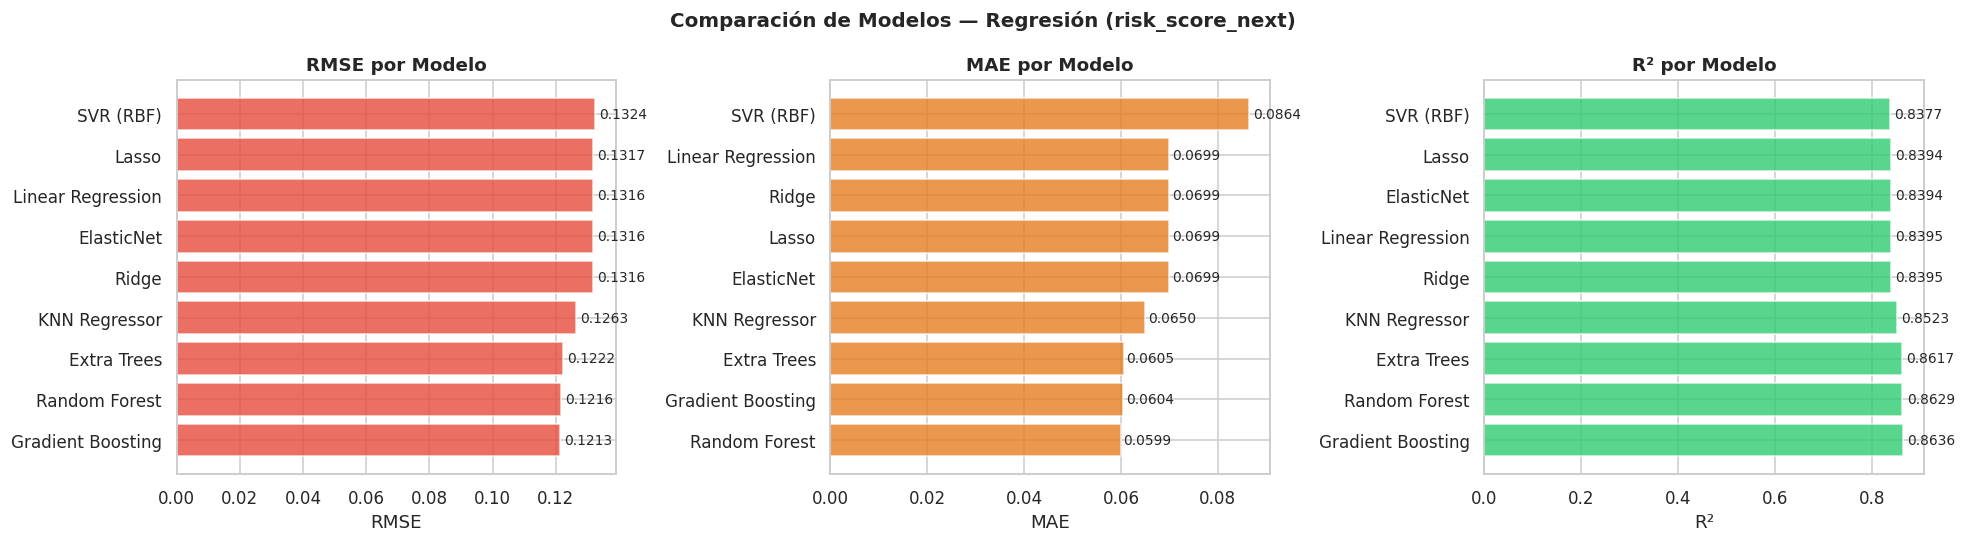

In [ ]:
# ── Visualización: métricas de regresión ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_r = ['RMSE', 'MAE', 'R²']
ascending_r = [True, True, False]
colors_r = ['#e74c3c', '#e67e22', '#2ecc71']

for ax, metric, asc, color in zip(axes, metrics_r, ascending_r, colors_r):
    data = df_reg.sort_values(metric, ascending=asc)
    bars = ax.barh(data['Modelo'], data[metric], color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{metric} por Modelo', fontweight='bold')
    ax.set_xlabel(metric)
    for bar, val in zip(bars, data[metric]):
        ax.text(bar.get_width() + bar.get_width()*0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.suptitle('Comparación de Modelos — Regresión (risk_score_next)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

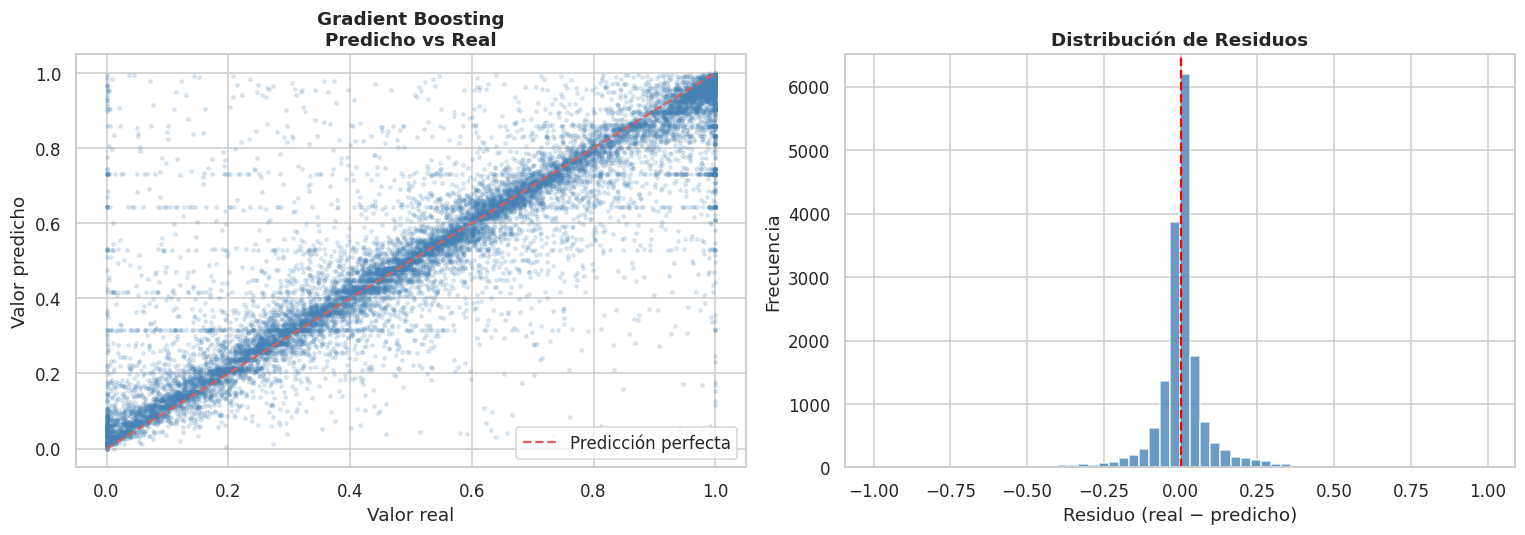

🏆 Mejor modelo de regresión: Gradient Boosting  |  RMSE=0.12133  |  R²=0.86362


In [ ]:
# ── Predicho vs Real: mejor modelo ────────────────────────────────────────
best_reg_name = df_reg.iloc[0]['Modelo']
best_reg_model = regression_models[best_reg_name]
y_pred_best_r = np.clip(best_reg_model.predict(X_test_r), 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter real vs predicho
axes[0].scatter(y_test_r, y_pred_best_r, alpha=0.15, s=5, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', lw=1.5, label='Predicción perfecta')
axes[0].set_xlabel('Valor real')
axes[0].set_ylabel('Valor predicho')
axes[0].set_title(f'{best_reg_name}\nPredicho vs Real', fontweight='bold')
axes[0].legend()

# Distribución de residuos
residuals = y_test_r.values - y_pred_best_r
axes[1].hist(residuals, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('Residuo (real − predicho)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos', fontweight='bold')

plt.tight_layout()
plt.show()
print(f'🏆 Mejor modelo de regresión: {best_reg_name}  |  RMSE={df_reg.iloc[0]["RMSE"]:.5f}  |  R²={df_reg.iloc[0]["R²"]:.5f}')

---
## 5. Modelamiento — Tarea 2: Clasificación Binaria (`target_distress_next`)

Modelos: **Logistic Regression, Decision Tree, KNN, Naive Bayes, SVM, Random Forest, Gradient Boosting, Extra Trees**

In [ ]:
# ── Definición de modelos de clasificación binaria ─────────────────────────
binary_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, C=0.5),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'KNN Classifier'      : KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    'Naive Bayes'         : GaussianNB(),
    'SVM (RBF)'           : SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=RANDOM_STATE),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
}

print(f'🔢 Total modelos clasificación binaria: {len(binary_models)}')

🔢 Total modelos clasificación binaria: 8


In [ ]:
# ── Entrenamiento y evaluación ──────────────────────────────────────────────
bin_results = []

for name, model in binary_models.items():
    print(f'  ⏳ Entrenando: {name}...')
    model.fit(X_train_b, y_train_b)
    y_pred   = model.predict(X_test_b)
    y_prob   = model.predict_proba(X_test_b)[:, 1] if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test_b, y_pred)
    prec = precision_score(y_test_b, y_pred, zero_division=0)
    rec  = recall_score(y_test_b, y_pred, zero_division=0)
    f1   = f1_score(y_test_b, y_pred, zero_division=0)
    roc  = roc_auc_score(y_test_b, y_prob) if y_prob is not None else np.nan

    bin_results.append({
        'Modelo'    : name,
        'Accuracy'  : round(acc,  4),
        'Precision' : round(prec, 4),
        'Recall'    : round(rec,  4),
        'F1-Score'  : round(f1,   4),
        'ROC-AUC'   : round(roc,  4) if not np.isnan(roc) else '—',
    })

df_bin = pd.DataFrame(bin_results).sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_bin.index += 1
print('\n✅ Evaluación clasificación binaria completada.')
df_bin

  ⏳ Entrenando: Logistic Regression...
  ⏳ Entrenando: Decision Tree...
  ⏳ Entrenando: KNN Classifier...
  ⏳ Entrenando: Naive Bayes...
  ⏳ Entrenando: SVM (RBF)...
  ⏳ Entrenando: Random Forest...
  ⏳ Entrenando: Gradient Boosting...
  ⏳ Entrenando: Extra Trees...

✅ Evaluación clasificación binaria completada.


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Gradient Boosting,0.9361,0.9464,0.9466,0.9465,0.9767
2,Random Forest,0.9349,0.9446,0.9465,0.9456,0.9767
3,Extra Trees,0.9340,0.9395,0.9507,0.9451,0.9742
4,Decision Tree,0.9316,0.9438,0.9415,0.9427,0.9625
5,KNN Classifier,0.9295,0.9469,0.9344,0.9406,0.9677
6,SVM (RBF),0.9244,0.9260,0.9493,0.9375,0.9645
7,Logistic Regression,0.9197,0.9248,0.9421,0.9334,0.9686
8,Naive Bayes,0.8740,0.9474,0.8355,0.8879,0.9556


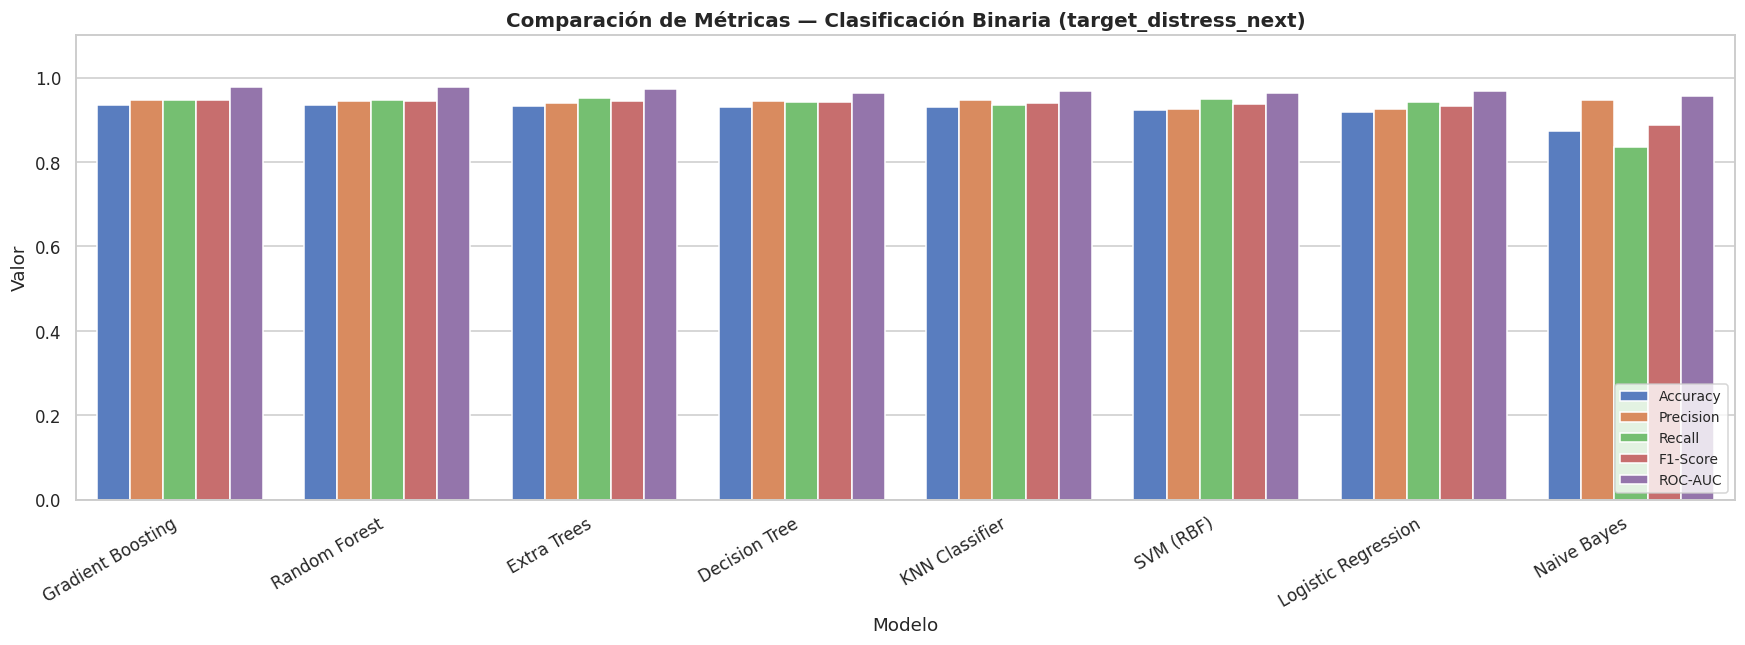

In [ ]:
# ── Visualización: métricas clasificación binaria ──────────────────────────
metrics_b = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
df_bin_plot = df_bin.copy()
df_bin_plot['ROC-AUC'] = pd.to_numeric(df_bin_plot['ROC-AUC'], errors='coerce')

df_melt_b = df_bin_plot.melt(id_vars='Modelo', value_vars=metrics_b, var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=df_melt_b, x='Modelo', y='Valor', hue='Métrica', ax=ax)
ax.set_title('Comparación de Métricas — Clasificación Binaria (target_distress_next)', fontweight='bold', fontsize=13)
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.1)
ax.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

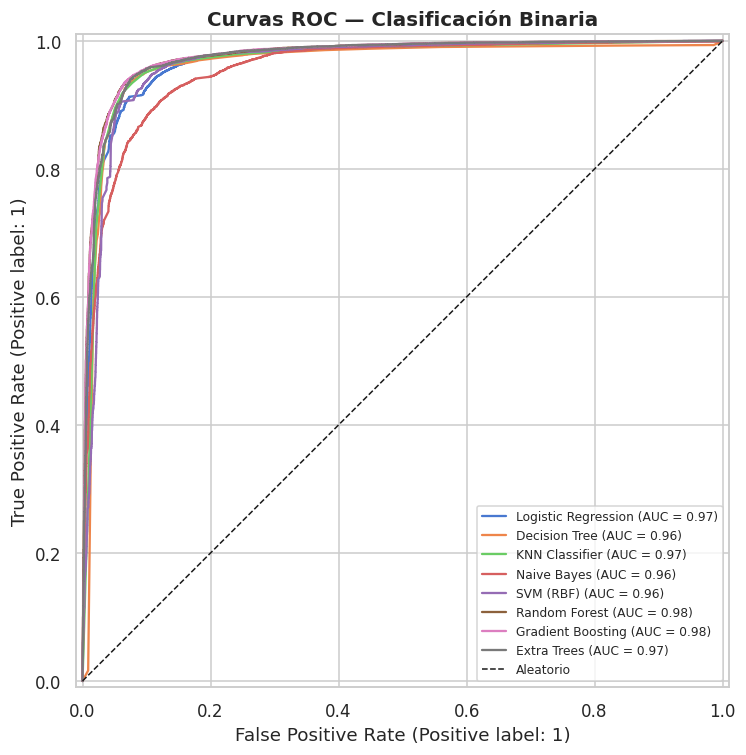

In [ ]:
# ── Curvas ROC: todos los modelos ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))

for name, model in binary_models.items():
    if hasattr(model, 'predict_proba'):
        y_prob_roc = model.predict_proba(X_test_b)[:, 1]
        RocCurveDisplay.from_predictions(y_test_b, y_prob_roc, name=name, ax=ax)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatorio')
ax.set_title('Curvas ROC — Clasificación Binaria', fontweight='bold', fontsize=13)
ax.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

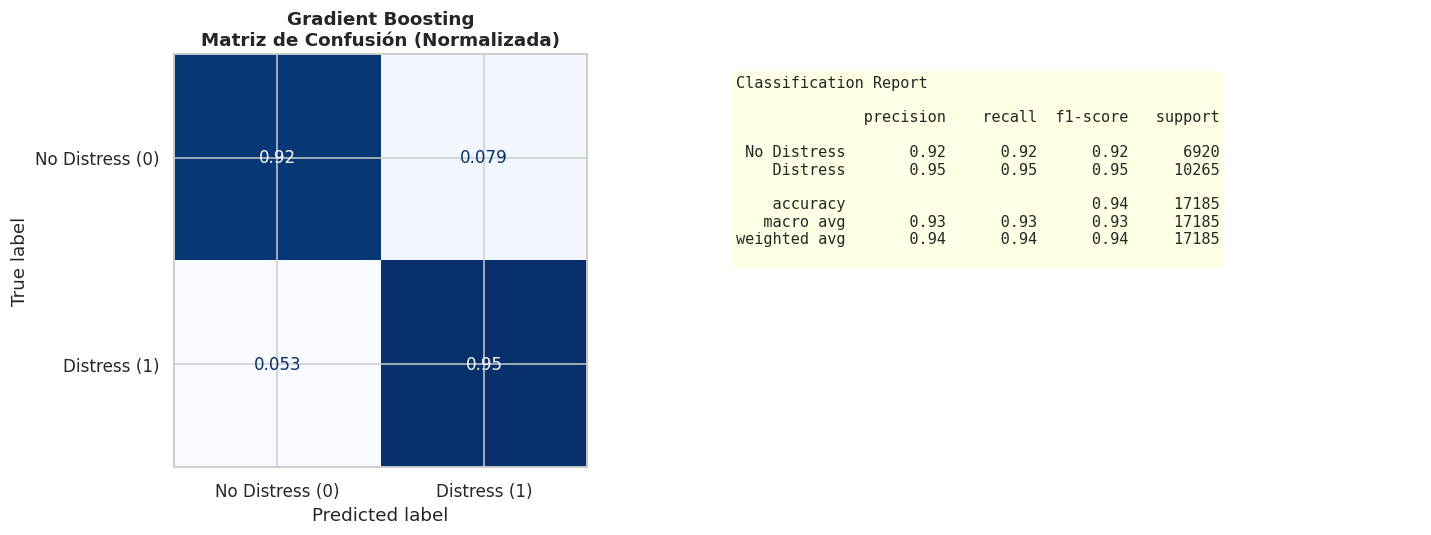

🏆 Mejor modelo binario: Gradient Boosting  |  F1=0.9465  |  ROC-AUC=0.9767


In [ ]:
# ── Matriz de confusión: mejor modelo ─────────────────────────────────────
best_bin_name  = df_bin.iloc[0]['Modelo']
best_bin_model = binary_models[best_bin_name]
y_pred_best_b  = best_bin_model.predict(X_test_b)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión normalizada
cm_norm = confusion_matrix(y_test_b, y_pred_best_b, normalize='true')
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['No Distress (0)', 'Distress (1)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_bin_name}\nMatriz de Confusión (Normalizada)', fontweight='bold')

# Reporte de clasificación como texto
report = classification_report(y_test_b, y_pred_best_b, target_names=['No Distress', 'Distress'])
axes[1].axis('off')
axes[1].text(0.05, 0.95, 'Classification Report\n\n' + report,
             transform=axes[1].transAxes, fontsize=10, verticalalignment='top',
             fontfamily='monospace', bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()
print(f'🏆 Mejor modelo binario: {best_bin_name}  |  F1={df_bin.iloc[0]["F1-Score"]:.4f}  |  ROC-AUC={df_bin.iloc[0]["ROC-AUC"]}')

---
## 6. Modelamiento — Tarea 3: Clasificación Multiclase (`target_class_next`)

Clases: **0 = Riesgo Bajo | 1 = Riesgo Medio | 2 = Riesgo Alto**

Modelos: **Logistic Regression, Decision Tree, KNN, Naive Bayes, SVM, Random Forest, Gradient Boosting, Extra Trees**

In [ ]:
# ── Definición de modelos multiclase ───────────────────────────────────────
multiclass_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=RANDOM_STATE, C=0.5),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=RANDOM_STATE),
    'KNN Classifier'      : KNeighborsClassifier(n_neighbors=10, n_jobs=-1),
    'Naive Bayes'         : GaussianNB(),
    'SVM (RBF)'           : SVC(kernel='rbf', C=1.0, probability=True, random_state=RANDOM_STATE, decision_function_shape='ovr'),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=RANDOM_STATE),
    'Extra Trees'         : ExtraTreesClassifier(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1),
}

print(f'🔢 Total modelos clasificación multiclase: {len(multiclass_models)}')

🔢 Total modelos clasificación multiclase: 8


In [ ]:
# ── Entrenamiento y evaluación ──────────────────────────────────────────────
mc_results = []

for name, model in multiclass_models.items():
    print(f'  ⏳ Entrenando: {name}...')
    model.fit(X_train_m, y_train_m)
    y_pred = model.predict(X_test_m)
    y_prob = model.predict_proba(X_test_m) if hasattr(model, 'predict_proba') else None

    acc      = accuracy_score(y_test_m, y_pred)
    f1_mac   = f1_score(y_test_m, y_pred, average='macro',   zero_division=0)
    f1_wt    = f1_score(y_test_m, y_pred, average='weighted', zero_division=0)
    prec_mac = precision_score(y_test_m, y_pred, average='macro',   zero_division=0)
    rec_mac  = recall_score(y_test_m, y_pred, average='macro',   zero_division=0)
    roc_ovr  = roc_auc_score(y_test_m, y_prob, multi_class='ovr', average='macro') if y_prob is not None else np.nan

    mc_results.append({
        'Modelo'           : name,
        'Accuracy'         : round(acc,      4),
        'F1 Macro'         : round(f1_mac,   4),
        'F1 Weighted'      : round(f1_wt,    4),
        'Precision Macro'  : round(prec_mac, 4),
        'Recall Macro'     : round(rec_mac,  4),
        'ROC-AUC OvR'      : round(roc_ovr,  4) if not np.isnan(roc_ovr) else '—',
    })

df_mc = pd.DataFrame(mc_results).sort_values('F1 Macro', ascending=False).reset_index(drop=True)
df_mc.index += 1
print('\n✅ Evaluación clasificación multiclase completada.')
df_mc

  ⏳ Entrenando: Logistic Regression...
  ⏳ Entrenando: Decision Tree...
  ⏳ Entrenando: KNN Classifier...
  ⏳ Entrenando: Naive Bayes...
  ⏳ Entrenando: SVM (RBF)...
  ⏳ Entrenando: Random Forest...
  ⏳ Entrenando: Gradient Boosting...
  ⏳ Entrenando: Extra Trees...

✅ Evaluación clasificación multiclase completada.


,Modelo,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC OvR
1,Gradient Boosting,0.8915,0.8802,0.8911,0.8817,0.8788,0.9682
2,Random Forest,0.8903,0.8788,0.8899,0.8802,0.8776,0.9684
3,Decision Tree,0.8860,0.8741,0.8859,0.8750,0.8733,0.9517
4,Extra Trees,0.8827,0.8708,0.8828,0.8726,0.8694,0.9654
5,KNN Classifier,0.8813,0.8689,0.8809,0.8700,0.8680,0.9558
6,SVM (RBF),0.8766,0.8641,0.8765,0.8676,0.8615,0.9539
7,Logistic Regression,0.8594,0.8435,0.8585,0.8453,0.8420,0.9506
8,Naive Bayes,0.8394,0.8312,0.8434,0.8317,0.8379,0.9402


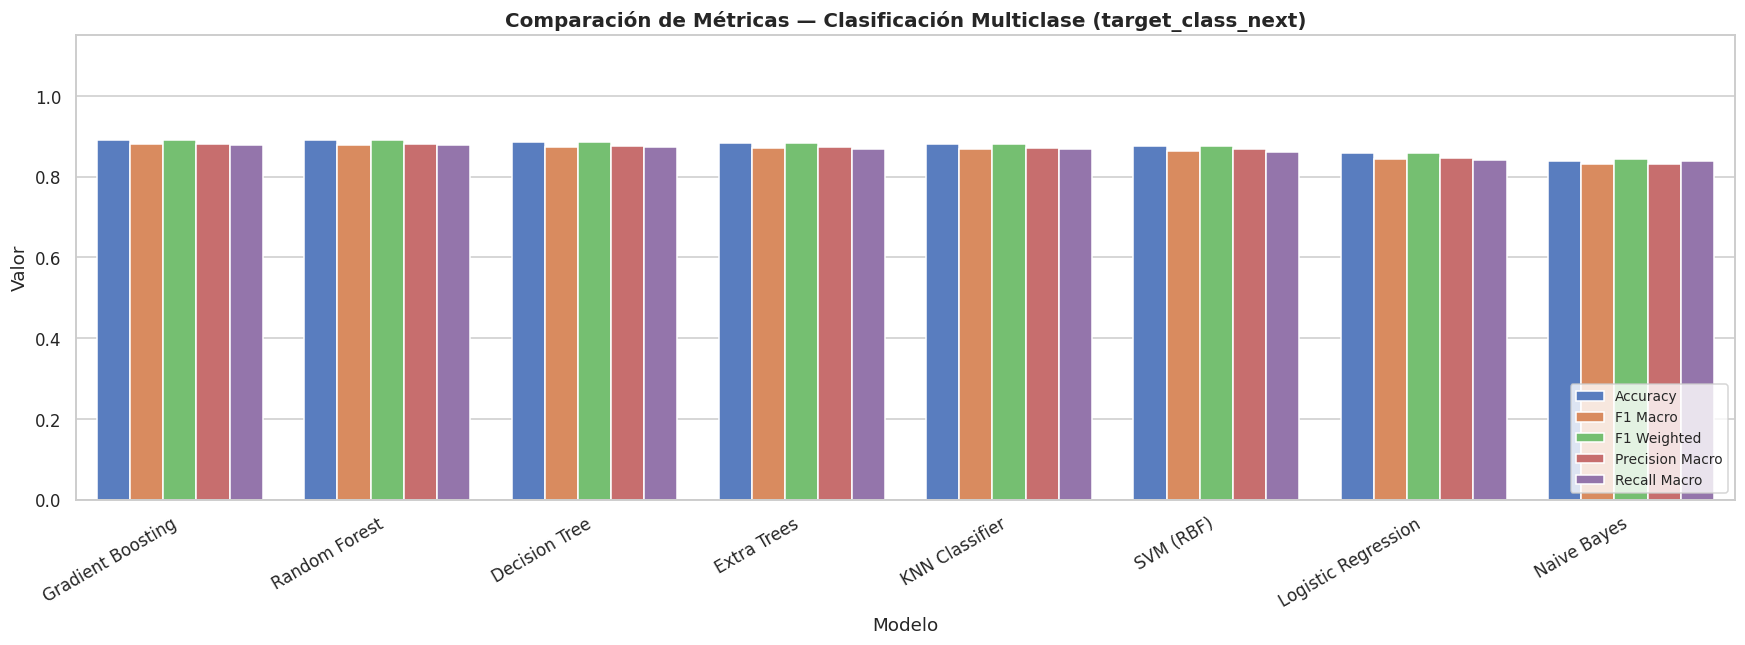

In [ ]:
# ── Visualización: métricas multiclase ─────────────────────────────────────
metrics_mc_plot = ['Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision Macro', 'Recall Macro']
df_mc_plot = df_mc.copy()

df_melt_mc = df_mc_plot.melt(id_vars='Modelo', value_vars=metrics_mc_plot, var_name='Métrica', value_name='Valor')

fig, ax = plt.subplots(figsize=(16, 6))
sns.barplot(data=df_melt_mc, x='Modelo', y='Valor', hue='Métrica', ax=ax)
ax.set_title('Comparación de Métricas — Clasificación Multiclase (target_class_next)', fontweight='bold', fontsize=13)
ax.set_xlabel('Modelo')
ax.set_ylabel('Valor')
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right', fontsize=9)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

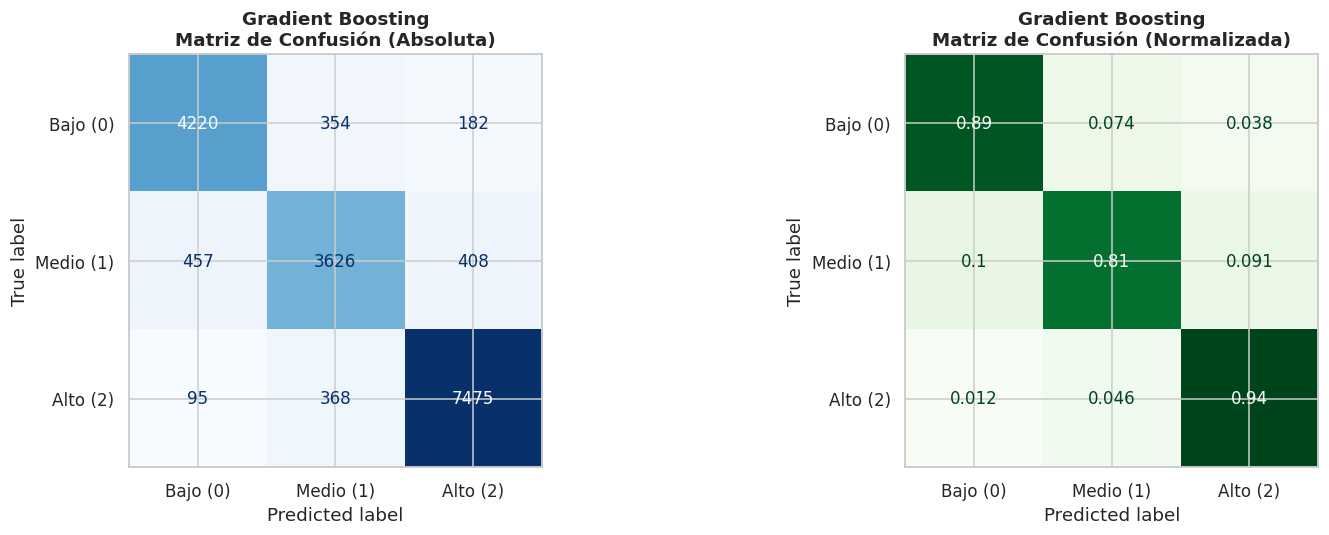


Classification Report — Gradient Boosting
              precision    recall  f1-score   support

    Bajo (0)       0.88      0.89      0.89      4756
   Medio (1)       0.83      0.81      0.82      4491
    Alto (2)       0.93      0.94      0.93      7938

    accuracy                           0.89     17185
   macro avg       0.88      0.88      0.88     17185
weighted avg       0.89      0.89      0.89     17185

🏆 Mejor modelo multiclase: Gradient Boosting  |  F1 Macro=0.8802


In [ ]:
# ── Matrices de confusión: mejor modelo ────────────────────────────────────
best_mc_name  = df_mc.iloc[0]['Modelo']
best_mc_model = multiclass_models[best_mc_name]
y_pred_best_m = best_mc_model.predict(X_test_m)

class_names = ['Bajo (0)', 'Medio (1)', 'Alto (2)']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Absoluta
cm_abs = confusion_matrix(y_test_m, y_pred_best_m)
ConfusionMatrixDisplay(confusion_matrix=cm_abs, display_labels=class_names).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'{best_mc_name}\nMatriz de Confusión (Absoluta)', fontweight='bold')

# Normalizada
cm_norm = confusion_matrix(y_test_m, y_pred_best_m, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title(f'{best_mc_name}\nMatriz de Confusión (Normalizada)', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nClassification Report — {best_mc_name}')
print(classification_report(y_test_m, y_pred_best_m, target_names=class_names))
print(f'🏆 Mejor modelo multiclase: {best_mc_name}  |  F1 Macro={df_mc.iloc[0]["F1 Macro"]:.4f}')

---
## 7. Importancia de Features — Mejores Modelos

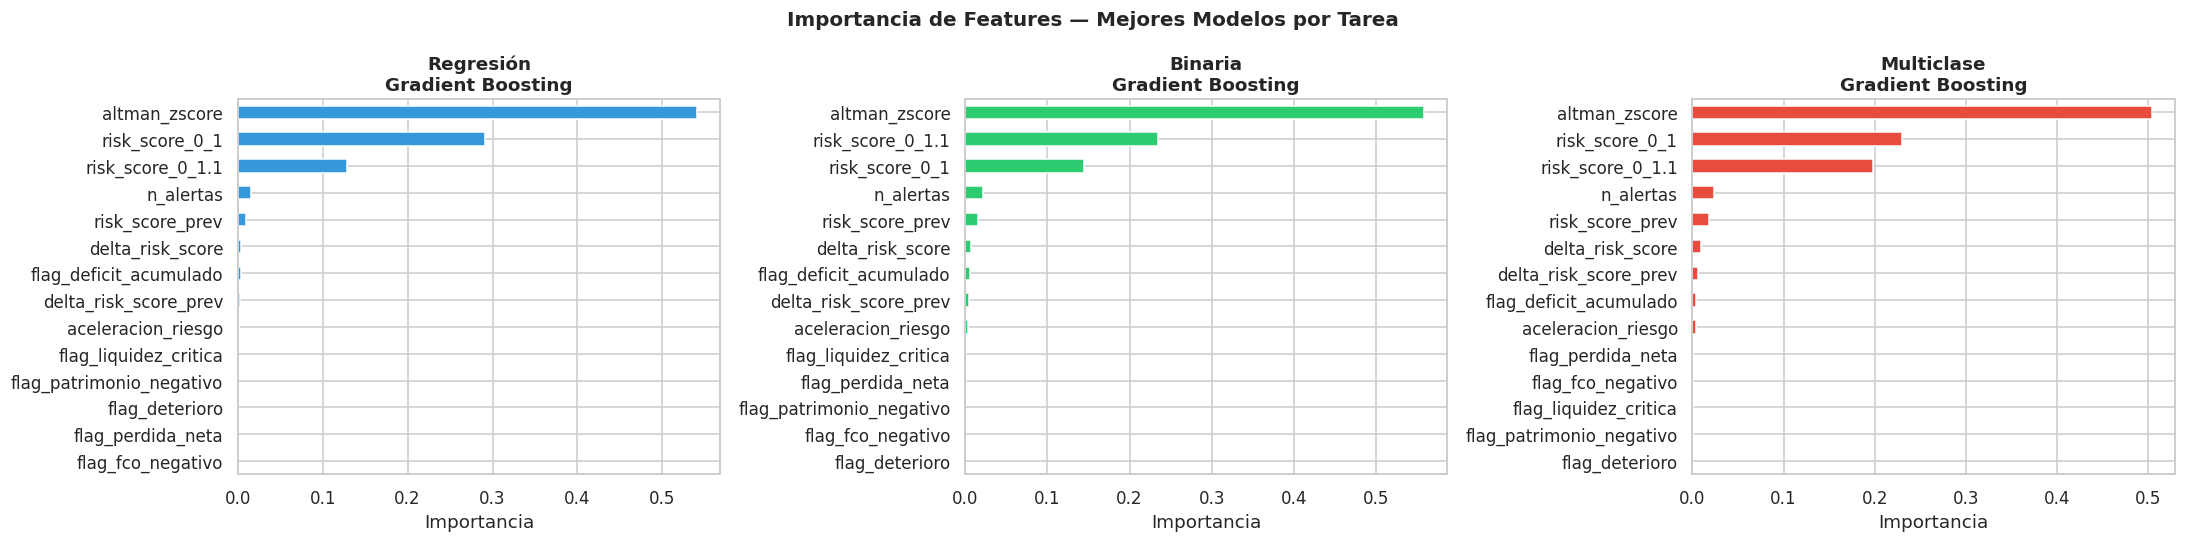

In [ ]:
def plot_feature_importance(model, feature_names, title, ax, color='steelblue', top_n=14):
    """Grafica importancia de features para modelos basados en árboles."""
    if not hasattr(model, 'feature_importances_'):
        ax.set_visible(False)
        return
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True).tail(top_n)
    importances.plot(kind='barh', ax=ax, color=color, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Importancia')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

plot_feature_importance(best_reg_model,  FEATURE_COLS, f'Regresión\n{best_reg_name}',  axes[0], color='#3498db')
plot_feature_importance(best_bin_model,  FEATURE_COLS, f'Binaria\n{best_bin_name}',    axes[1], color='#2ecc71')
plot_feature_importance(best_mc_model,   FEATURE_COLS, f'Multiclase\n{best_mc_name}',  axes[2], color='#e74c3c')

plt.suptitle('Importancia de Features — Mejores Modelos por Tarea', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 8. Validación Cruzada — Mejores Modelos

In [ ]:
print('🔄 Validación cruzada (5-fold) — mejores modelos por tarea...')
cv_results = {}

# Regresión
cv_r = cross_val_score(best_reg_model, X_processed, y_reg, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE),
                       scoring='r2', n_jobs=-1)
cv_results[f'Regresión — {best_reg_name} (R²)'] = cv_r
print(f'  ✅ Regresión ({best_reg_name})   R²: {cv_r.mean():.4f} ± {cv_r.std():.4f}')

# Binaria
cv_b = cross_val_score(best_bin_model, X_processed, y_bin,
                       cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                       scoring='f1', n_jobs=-1)
cv_results[f'Binaria — {best_bin_name} (F1)'] = cv_b
print(f'  ✅ Binaria    ({best_bin_name})  F1 : {cv_b.mean():.4f} ± {cv_b.std():.4f}')

# Multiclase
cv_m = cross_val_score(best_mc_model, X_processed, y_mc,
                       cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                       scoring='f1_macro', n_jobs=-1)
cv_results[f'Multiclase — {best_mc_name} (F1 Macro)'] = cv_m
print(f'  ✅ Multiclase ({best_mc_name})  F1M: {cv_m.mean():.4f} ± {cv_m.std():.4f}')

🔄 Validación cruzada (5-fold) — mejores modelos por tarea...
  ✅ Regresión (Gradient Boosting)   R²: 0.8681 ± 0.0029
  ✅ Binaria    (Gradient Boosting)  F1 : 0.9468 ± 0.0015
  ✅ Multiclase (Gradient Boosting)  F1M: 0.8816 ± 0.0016


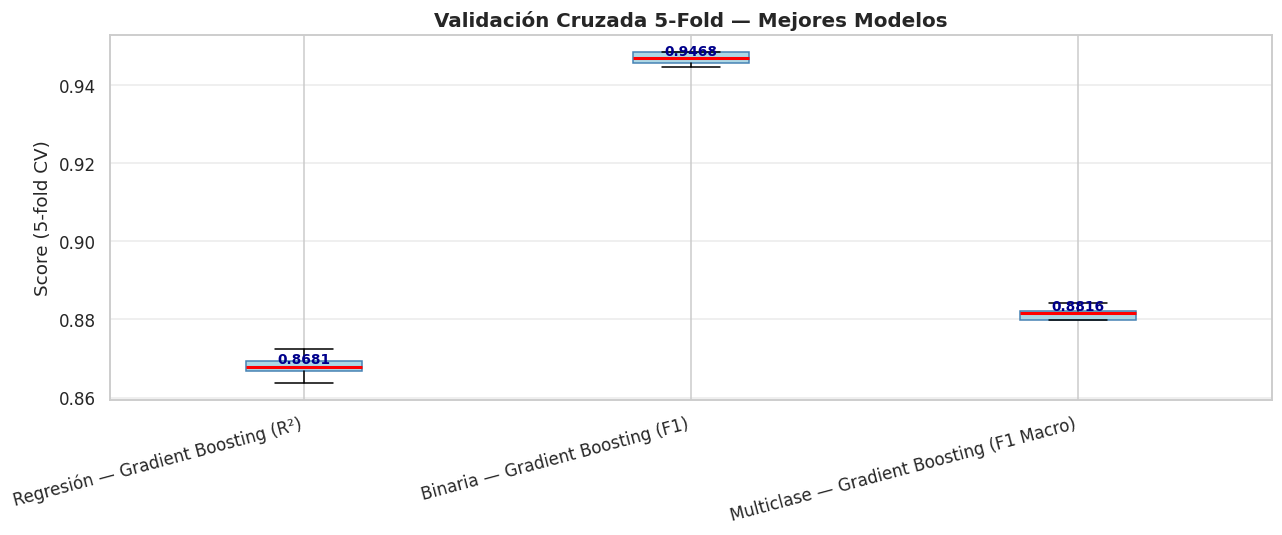

In [ ]:
# ── Boxplot de validación cruzada ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

labels = list(cv_results.keys())
data   = [cv_results[k] for k in labels]

bp = ax.boxplot(data, patch_artist=True, vert=True,
                boxprops=dict(facecolor='lightblue', color='steelblue'),
                medianprops=dict(color='red', linewidth=2))

ax.set_xticks(range(1, len(labels)+1))
ax.set_xticklabels(labels, rotation=15, ha='right')
ax.set_ylabel('Score (5-fold CV)')
ax.set_title('Validación Cruzada 5-Fold — Mejores Modelos', fontweight='bold', fontsize=13)
ax.grid(axis='y', alpha=0.4)

for i, d in enumerate(data, 1):
    ax.text(i, d.mean(), f'{d.mean():.4f}', ha='center', va='bottom', fontsize=9, color='darkblue', fontweight='bold')

plt.tight_layout()
plt.show()

---
## 9. 📋 Tabla de Comparación Global — Resumen por Variable Objetivo

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TAREA 1 — REGRESIÓN: risk_score_next
# ══════════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('📌 TAREA 1 — REGRESIÓN: risk_score_next')
print('=' * 70)
df_reg_show = df_reg[['Modelo', 'RMSE', 'MAE', 'R²', 'MAPE']].copy()
df_reg_show = df_reg_show.sort_values('RMSE').reset_index(drop=True)
df_reg_show.index += 1
# Destacar mejor fila
def highlight_best_reg(row):
    return ['background-color: #d4edda; font-weight: bold' if row.name == 1 else '' for _ in row]
display(df_reg_show.style.apply(highlight_best_reg, axis=1).format({'RMSE':'{:.5f}','MAE':'{:.5f}','R²':'{:.5f}','MAPE':'{:.5f}'}))
print(f'\n   🏆 Mejor: {df_reg_show.iloc[0]["Modelo"]} — RMSE={df_reg_show.iloc[0]["RMSE"]:.5f}, R²={df_reg_show.iloc[0]["R²"]:.5f}')

📌 TAREA 1 — REGRESIÓN: risk_score_next


,Modelo,RMSE,MAE,R²,MAPE
1,Gradient Boosting,0.12133,0.06043,0.86362,0.81246
2,Random Forest,0.12165,0.05991,0.86291,0.78292
3,Extra Trees,0.12220,0.06054,0.86167,0.79104
4,KNN Regressor,0.12627,0.06502,0.85229,0.85480
5,Ridge,0.13165,0.06993,0.83945,0.94158
6,ElasticNet,0.13165,0.06991,0.83944,0.94563
7,Linear Regression,0.13165,0.06993,0.83945,0.94156
8,Lasso,0.13167,0.06992,0.83938,0.94936
9,SVR (RBF),0.13237,0.08640,0.83767,1.09527



   🏆 Mejor: Gradient Boosting — RMSE=0.12133, R²=0.86362


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TAREA 2 — CLASIFICACIÓN BINARIA: target_distress_next
# ══════════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('📌 TAREA 2 — CLASIFICACIÓN BINARIA: target_distress_next')
print('=' * 70)
df_bin_show = df_bin[['Modelo', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']].copy()
df_bin_show = df_bin_show.sort_values('F1-Score', ascending=False).reset_index(drop=True)
df_bin_show.index += 1
def highlight_best_bin(row):
    return ['background-color: #d4edda; font-weight: bold' if row.name == 1 else '' for _ in row]
display(df_bin_show.style.apply(highlight_best_bin, axis=1).format({'Accuracy':'{:.4f}','Precision':'{:.4f}','Recall':'{:.4f}','F1-Score':'{:.4f}'}))
print(f'\n   🏆 Mejor: {df_bin_show.iloc[0]["Modelo"]} — F1={df_bin_show.iloc[0]["F1-Score"]:.4f}, ROC-AUC={df_bin_show.iloc[0]["ROC-AUC"]}')

📌 TAREA 2 — CLASIFICACIÓN BINARIA: target_distress_next


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,Gradient Boosting,0.9361,0.9464,0.9466,0.9465,0.976700
2,Random Forest,0.9349,0.9446,0.9465,0.9456,0.976700
3,Extra Trees,0.9340,0.9395,0.9507,0.9451,0.974200
4,Decision Tree,0.9316,0.9438,0.9415,0.9427,0.962500
5,KNN Classifier,0.9295,0.9469,0.9344,0.9406,0.967700
6,SVM (RBF),0.9244,0.9260,0.9493,0.9375,0.964500
7,Logistic Regression,0.9197,0.9248,0.9421,0.9334,0.968600
8,Naive Bayes,0.8740,0.9474,0.8355,0.8879,0.955600



   🏆 Mejor: Gradient Boosting — F1=0.9465, ROC-AUC=0.9767


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TAREA 3 — CLASIFICACIÓN MULTICLASE: target_class_next
# ══════════════════════════════════════════════════════════════════════════════
print('=' * 70)
print('📌 TAREA 3 — CLASIFICACIÓN MULTICLASE: target_class_next')
print('=' * 70)
df_mc_show = df_mc[['Modelo', 'Accuracy', 'F1 Macro', 'F1 Weighted', 'Precision Macro', 'Recall Macro', 'ROC-AUC OvR']].copy()
df_mc_show = df_mc_show.sort_values('F1 Macro', ascending=False).reset_index(drop=True)
df_mc_show.index += 1
def highlight_best_mc(row):
    return ['background-color: #d4edda; font-weight: bold' if row.name == 1 else '' for _ in row]
display(df_mc_show.style.apply(highlight_best_mc, axis=1).format({'Accuracy':'{:.4f}','F1 Macro':'{:.4f}','F1 Weighted':'{:.4f}','Precision Macro':'{:.4f}','Recall Macro':'{:.4f}'}))
print(f'\n   🏆 Mejor: {df_mc_show.iloc[0]["Modelo"]} — F1 Macro={df_mc_show.iloc[0]["F1 Macro"]:.4f}')

📌 TAREA 3 — CLASIFICACIÓN MULTICLASE: target_class_next


,Modelo,Accuracy,F1 Macro,F1 Weighted,Precision Macro,Recall Macro,ROC-AUC OvR
1,Gradient Boosting,0.8915,0.8802,0.8911,0.8817,0.8788,0.968200
2,Random Forest,0.8903,0.8788,0.8899,0.8802,0.8776,0.968400
3,Decision Tree,0.8860,0.8741,0.8859,0.8750,0.8733,0.951700
4,Extra Trees,0.8827,0.8708,0.8828,0.8726,0.8694,0.965400
5,KNN Classifier,0.8813,0.8689,0.8809,0.8700,0.8680,0.955800
6,SVM (RBF),0.8766,0.8641,0.8765,0.8676,0.8615,0.953900
7,Logistic Regression,0.8594,0.8435,0.8585,0.8453,0.8420,0.950600
8,Naive Bayes,0.8394,0.8312,0.8434,0.8317,0.8379,0.940200



   🏆 Mejor: Gradient Boosting — F1 Macro=0.8802


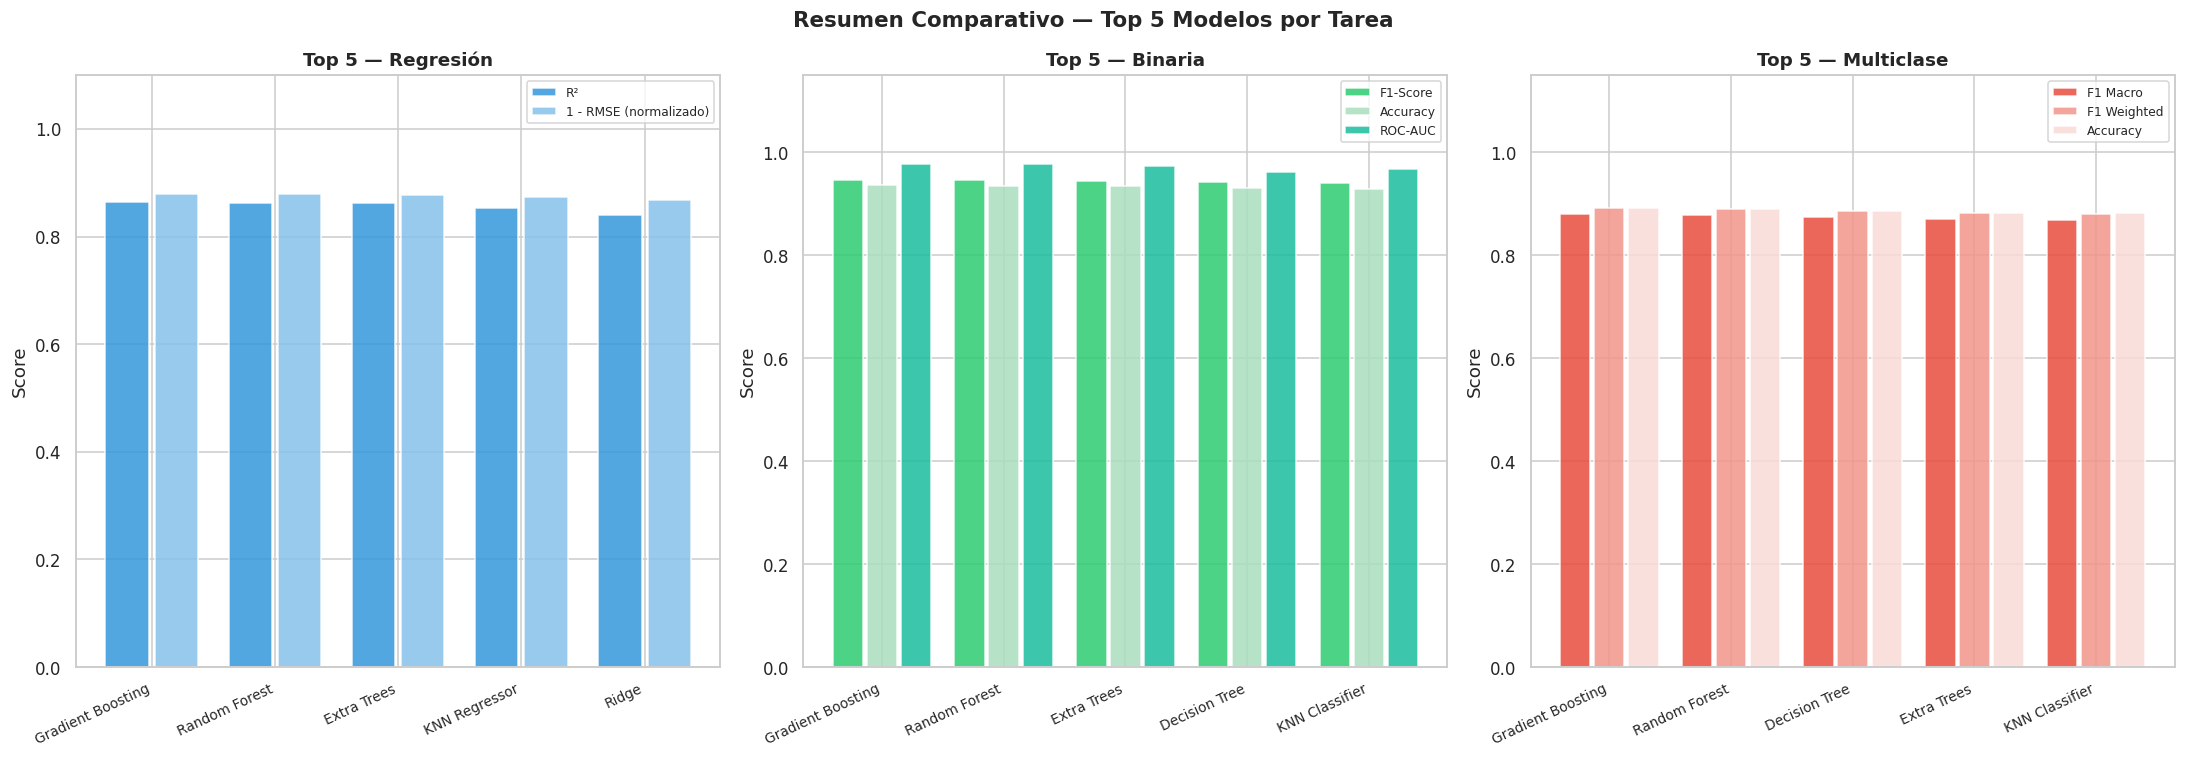

In [ ]:
# ── Gráfico resumen: radar de mejores modelos ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

# --- Panel 1: Regresión ---
ax = axes[0]
top5_r = df_reg_show.head(5)
x = np.arange(len(top5_r))
ax.bar(x, top5_r['R²'], color='#3498db', alpha=0.85, label='R²', width=0.35)
ax.bar(x + 0.4, 1 - top5_r['RMSE'], color='#85c1e9', alpha=0.85, label='1 - RMSE (normalizado)', width=0.35)
ax.set_xticks(x + 0.2)
ax.set_xticklabels(top5_r['Modelo'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title('Top 5 — Regresión', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylabel('Score')

# --- Panel 2: Binaria ---
ax = axes[1]
top5_b = df_bin_show.head(5)
x = np.arange(len(top5_b))
ax.bar(x, top5_b['F1-Score'], color='#2ecc71', alpha=0.85, label='F1-Score', width=0.25)
ax.bar(x + 0.28, top5_b['Accuracy'], color='#a9dfbf', alpha=0.85, label='Accuracy', width=0.25)
roc_vals = pd.to_numeric(top5_b['ROC-AUC'], errors='coerce').fillna(0)
ax.bar(x + 0.56, roc_vals, color='#1abc9c', alpha=0.85, label='ROC-AUC', width=0.25)
ax.set_xticks(x + 0.28)
ax.set_xticklabels(top5_b['Modelo'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title('Top 5 — Binaria', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylabel('Score')

# --- Panel 3: Multiclase ---
ax = axes[2]
top5_m = df_mc_show.head(5)
x = np.arange(len(top5_m))
ax.bar(x, top5_m['F1 Macro'], color='#e74c3c', alpha=0.85, label='F1 Macro', width=0.25)
ax.bar(x + 0.28, top5_m['F1 Weighted'], color='#f1948a', alpha=0.85, label='F1 Weighted', width=0.25)
ax.bar(x + 0.56, top5_m['Accuracy'], color='#fadbd8', alpha=0.85, label='Accuracy', width=0.25)
ax.set_xticks(x + 0.28)
ax.set_xticklabels(top5_m['Modelo'], rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.15)
ax.set_title('Top 5 — Multiclase', fontweight='bold')
ax.legend(fontsize=8)
ax.set_ylabel('Score')

plt.suptitle('Resumen Comparativo — Top 5 Modelos por Tarea', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 10. Conclusiones del Modelamiento


In [ ]:
print('=' * 70)
print('📊 RESUMEN FINAL — CRISP-DM: Fase de Modelamiento')
print('=' * 70)

print(f'''
┌─────────────────────────────────────────────────────────────────────┐
│  TAREA 1 — REGRESIÓN (risk_score_next)                              │
│  ✦ Mejor modelo : {best_reg_name:<44}│
│  ✦ RMSE         : {df_reg_show.iloc[0]["RMSE"]:<44.5f}│
│  ✦ R²           : {df_reg_show.iloc[0]["R²"]:<44.5f}│
│  ✦ MAE          : {df_reg_show.iloc[0]["MAE"]:<44.5f}│
├─────────────────────────────────────────────────────────────────────┤
│  TAREA 2 — CLASIFICACIÓN BINARIA (target_distress_next)             │
│  ✦ Mejor modelo : {best_bin_name:<44}│
│  ✦ F1-Score     : {df_bin_show.iloc[0]["F1-Score"]:<44.4f}│
│  ✦ Accuracy     : {df_bin_show.iloc[0]["Accuracy"]:<44.4f}│
│  ✦ ROC-AUC      : {str(df_bin_show.iloc[0]["ROC-AUC"]):<44}│
├─────────────────────────────────────────────────────────────────────┤
│  TAREA 3 — CLASIFICACIÓN MULTICLASE (target_class_next)             │
│  ✦ Mejor modelo : {best_mc_name:<44}│
│  ✦ F1 Macro     : {df_mc_show.iloc[0]["F1 Macro"]:<44.4f}│
│  ✦ F1 Weighted  : {df_mc_show.iloc[0]["F1 Weighted"]:<44.4f}│
│  ✦ Accuracy     : {df_mc_show.iloc[0]["Accuracy"]:<44.4f}│
└─────────────────────────────────────────────────────────────────────┘
''')

print('Notas:')
print('  • Los modelos basados en árboles (RF, GB, ET) tienden a dominar dado')
print('    el carácter no lineal y mixto de los features financieros.')
print('  • El preprocesamiento usó imputación por mediana + StandardScaler.')
print('  • La validación cruzada (5-fold) confirma la estabilidad de los resultados.')
print('  • Próximos pasos: ajuste de hiperparámetros (GridSearch/Optuna) y análisis SHAP.')

📊 RESUMEN FINAL — CRISP-DM: Fase de Modelamiento

┌─────────────────────────────────────────────────────────────────────┐
│  TAREA 1 — REGRESIÓN (risk_score_next)                              │
│  ✦ Mejor modelo : Gradient Boosting                           │
│  ✦ RMSE         : 0.12133                                     │
│  ✦ R²           : 0.86362                                     │
│  ✦ MAE          : 0.06043                                     │
├─────────────────────────────────────────────────────────────────────┤
│  TAREA 2 — CLASIFICACIÓN BINARIA (target_distress_next)             │
│  ✦ Mejor modelo : Gradient Boosting                           │
│  ✦ F1-Score     : 0.9465                                      │
│  ✦ Accuracy     : 0.9361                                      │
│  ✦ ROC-AUC      : 0.9767                                      │
├─────────────────────────────────────────────────────────────────────┤
│  TAREA 3 — CLASIFICACIÓN MULTICLASE (target_class_next)     